# Stage 2 v3 — FNO with Physics-Based Non-Dimensional Normalization
**aero-fno** · Key contribution vs thunil / v1 / v2:

Instead of statistical z-score normalization, every sample is normalized
by its own flow conditions using aerodynamic coefficients:

```
INPUTS
  inlet_x / U_inf   → cos(AoA),  always [-1, 1]
  inlet_y / U_inf   → sin(AoA),  always [-1, 1]
  geometry          → binary 0/1, unchanged

OUTPUTS
  Cp  = (p - p_inf) / q_inf    → pressure coefficient, O(1)
  u*  = u / U_inf              → velocity ratio, ~[0, 2]
  v*  = v / U_inf              → velocity ratio, ~[-0.5, 0.5]
```

This makes every sample look the same scale to the model — no z-score stats needed.
Stagnation point is always Cp≈+1, suction peak Cp≈-2 to -4, freestream Cp≈0.

**Checkpoints saved to:** `aero-fno/checkpoints_v3/`

In [ ]:
# ── 0. Install & Mount ─────────────────────────────────────────────────────────
!pip install neuraloperator -q

from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DIR   = '/content/drive/MyDrive/aero-fno'
CONTENT_DIR = '/content'

if not os.path.exists('/content/data/train'):
    print('Extracting data...')
    os.system(f'tar -xzf "{DRIVE_DIR}/data_upload.tar.gz" -C "{CONTENT_DIR}"')
    print('Done.')
else:
    print('Data already extracted.')

n = len([f for f in os.listdir('/content/data/train') if f.endswith('.npz')])
print(f'Train files: {n}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.3 MB/s eta 0:00:00
Mounted at /content/drive
Extracting data...
Done.
Train files: 6400


In [ ]:
# ── 1. Imports & Device ────────────────────────────────────────────────────────
import os
import glob
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from neuralop.models import FNO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

Device : cuda
GPU    : Tesla T4


In [ ]:
# ── 2. AirfoilDataset v3 — physics-based non-dimensional normalization ──────────
#
# No norm_stats.npy needed — every sample normalizes itself using its own
# freestream velocity U_inf and dynamic pressure q_inf.
#
# This is the key contribution of v3:
#   - Cp, u*, v* are aerodynamic coefficients — O(1) by physics
#   - Model sees identical input/output scales regardless of Re
#   - Predictions are directly interpretable as aerodynamic quantities

class AirfoilDataset(Dataset):
    def __init__(self, data_dir, split='train', val_ratio=0.2):
        assert split in ('train', 'val')

        all_files = sorted(glob.glob(
            os.path.join(data_dir, '**', '*.npz'), recursive=True
        ))
        if not all_files:
            raise FileNotFoundError(f'No .npz files found under: {data_dir}')

        n_val   = max(1, int(len(all_files) * val_ratio))
        n_train = len(all_files) - n_val
        self.files = all_files[:n_train] if split == 'train' else all_files[n_train:]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        arr = np.load(self.files[idx])['a'].astype(np.float32)  # (6,128,128)

        # ── Compute flow scalars ───────────────────────────────────────────
        Ux    = float(arr[0].mean())                    # freestream x-velocity
        Uy    = float(arr[1].mean())                    # freestream y-velocity
        U_inf = float(np.sqrt(Ux**2 + Uy**2))          # freestream speed
        U_inf = max(U_inf, 1e-6)                        # safety floor
        q_inf = 0.5 * 1.225 * U_inf**2                 # dynamic pressure
        q_inf = max(q_inf, 1e-6)                        # safety floor

        # ── Far-field static pressure ──────────────────────────────────────
        # Use corners of domain as freestream reference (away from airfoil)
        p_field = arr[3]                                # raw pressure (128,128)
        p_inf   = float(np.mean([
            p_field[:8,  :8].mean(),    # top-left corner
            p_field[:8,  -8:].mean(),   # top-right corner
            p_field[-8:, :8].mean(),    # bottom-left corner
            p_field[-8:, -8:].mean(),   # bottom-right corner
        ]))

        # ── Non-dimensional INPUTS ─────────────────────────────────────────
        inp = np.stack([
            arr[0] / U_inf,             # inlet_x / U_inf = cos(AoA)
            arr[1] / U_inf,             # inlet_y / U_inf = sin(AoA)
            arr[2],                     # geometry mask — unchanged
        ], axis=0).astype(np.float32)   # (3, 128, 128)

        # ── Non-dimensional OUTPUTS ────────────────────────────────────────
        Cp  = (arr[3] - p_inf) / q_inf  # pressure coefficient
        u_s = arr[4] / U_inf            # x-velocity ratio
        v_s = arr[5] / U_inf            # y-velocity ratio

        out = np.stack([Cp, u_s, v_s], axis=0).astype(np.float32)  # (3,128,128)

        return torch.from_numpy(inp), torch.from_numpy(out)

    def redimensionalise(self, out_nd, idx):
        """
        Convert non-dimensional predictions back to physical units.
        out_nd : (3, H, W) tensor — [Cp, u*, v*]
        Returns : (3, H, W) tensor — [pressure (Pa), u (m/s), v (m/s)]
        """
        arr   = np.load(self.files[idx])['a'].astype(np.float32)
        Ux    = float(arr[0].mean())
        Uy    = float(arr[1].mean())
        U_inf = max(float(np.sqrt(Ux**2 + Uy**2)), 1e-6)
        q_inf = max(0.5 * 1.225 * U_inf**2, 1e-6)
        p_inf = float(np.mean([
            arr[3][:8,  :8].mean(), arr[3][:8,  -8:].mean(),
            arr[3][-8:, :8].mean(), arr[3][-8:, -8:].mean(),
        ]))
        nd = out_nd.cpu().numpy()
        p  = nd[0] * q_inf + p_inf
        u  = nd[1] * U_inf
        v  = nd[2] * U_inf
        return np.stack([p, u, v], axis=0)


DATA_DIR = '/content/data/train'
train_ds = AirfoilDataset(DATA_DIR, split='train', val_ratio=0.2)
val_ds   = AirfoilDataset(DATA_DIR, split='val',   val_ratio=0.2)

print(f'Train samples : {len(train_ds)}')
print(f'Val   samples : {len(val_ds)}')

# ── Sanity check — all samples should now be in similar ranges ─────────────
print('\nSanity check — output ranges across 3 random samples:')
print(f'{"Sample":<10} {"Cp range":<25} {"u* range":<25} {"v* range"}')
print('-'*80)
for i in [0, 100, 1000, 2000, 4000]:
    _, y = train_ds[i]
    print(f'{i:<10} '
          f'[{y[0].min():.2f}, {y[0].max():.2f}]        '
          f'[{y[1].min():.2f}, {y[1].max():.2f}]        '
          f'[{y[2].min():.2f}, {y[2].max():.2f}]')
print('\nAll rows should show similar ranges — if so, normalization is working.')

Train samples : 5120
Val   samples : 1280

Sanity check — output ranges across 3 random samples:
Sample     Cp range                  u* range                  v* range
--------------------------------------------------------------------------------
0          [-1.03, 0.73]        [0.00, 1.50]        [-0.18, 0.66]
100        [-0.98, 0.76]        [0.00, 1.31]        [-0.63, 0.27]
1000       [-0.83, 0.65]        [0.00, 1.41]        [-0.17, 0.62]
2000       [-2.47, 1.01]        [-0.07, 1.91]        [-0.35, 1.05]
4000       [-2.09, 0.87]        [0.00, 1.50]        [-0.04, 1.03]

All rows should show similar ranges — if so, normalization is working.


In [ ]:
# ── 3. DataLoaders ─────────────────────────────────────────────────────────────
BATCH_SIZE  = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train batches/epoch : {len(train_loader)}')
print(f'Val   batches/epoch : {len(val_loader)}')

Train batches/epoch : 320
Val   batches/epoch : 80


In [ ]:
# ── 4. FNO Model ───────────────────────────────────────────────────────────────
model = FNO(
    n_modes=(48, 48),
    in_channels=3,
    out_channels=3,
    hidden_channels=64,
    n_layers=6,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'FNO parameter count: {total_params:,}')

with torch.no_grad():
    test_in  = torch.randn(2, 3, 128, 128).to(device)
    test_out = model(test_in)
    print(f'Forward pass: {tuple(test_in.shape)} → {tuple(test_out.shape)}  ✓')

FNO parameter count: 29,559,427
Forward pass: (2, 3, 128, 128) → (2, 3, 128, 128)  ✓


In [ ]:
# ── 5. Weighted Relative L2 Loss ───────────────────────────────────────────────
# Pressure weighted 2x — still harder than velocity even with Cp normalization
LOSS_WEIGHTS = torch.tensor([2.0, 1.0, 1.0], device=device)

def weighted_relative_l2(pred, target, weights=LOSS_WEIGHTS, eps=1e-8):
    w     = weights.view(1, 3, 1, 1)
    diff  = (pred - target) * w
    num   = diff.pow(2).sum(dim=(-2, -1)).sqrt()
    denom = (target * w).pow(2).sum(dim=(-2, -1)).sqrt() + eps
    return (num / denom).mean()

x_t = torch.randn(4, 3, 128, 128).to(device)
print(f'Loss identical : {weighted_relative_l2(x_t, x_t).item():.6f}  (should be ~0)')
print(f'Loss random    : {weighted_relative_l2(x_t, torch.randn_like(x_t)).item():.4f}  (should be ~1)')

Loss identical : 0.000000  (should be ~0)
Loss random    : 1.4097  (should be ~1)


In [ ]:
# ── 6. Optimizer & Scheduler ───────────────────────────────────────────────────
N_EPOCHS      = 50
LR            = 1e-3
WARMUP_EPOCHS = 5
PATIENCE      = 15   # early stopping

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

print(f'Optimizer  : Adam  lr={LR}  weight_decay=1e-4')
print(f'Scheduler  : Linear warmup ({WARMUP_EPOCHS} epochs) → CosineAnnealing')
print(f'Epochs     : {N_EPOCHS}  (early stop if no improvement for {PATIENCE} epochs)')

Optimizer  : Adam  lr=0.001  weight_decay=1e-4
Scheduler  : Linear warmup (5 epochs) → CosineAnnealing
Epochs     : 50  (early stop if no improvement for 15 epochs)


In [ ]:
# ── 7. Training Loop ───────────────────────────────────────────────────────────
CKPT_DIR = '/content/drive/MyDrive/aero-fno/checkpoints_v3'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f'Checkpoints → {CKPT_DIR}')

train_losses    = []
val_losses      = []
best_val        = float('inf')
epochs_no_improve = 0

print(f'Training FNO v3 for up to {N_EPOCHS} epochs on {device}...')
print('='*70)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = weighted_relative_l2(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred    = model(x_batch)
            loss    = weighted_relative_l2(pred, y_batch)
            epoch_val_loss += loss.item()
    epoch_val_loss /= len(val_loader)

    scheduler.step()
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch:>3d}/{N_EPOCHS} | '
          f'train={epoch_train_loss:.4f} | '
          f'val={epoch_val_loss:.4f} | '
          f'lr={lr_now:.2e} | '
          f'{elapsed:.1f}s')

    # ── Save best checkpoint ────────────────────────────────────────────────
    if epoch_val_loss < best_val:
        best_val = epoch_val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch'        : epoch,
            'model_state'  : model.state_dict(),
            'optim_state'  : optimizer.state_dict(),
            'val_loss'     : best_val,
            'train_losses' : train_losses,
            'val_losses'   : val_losses,
            'config': {
                'n_modes'         : (48, 48),
                'hidden_channels' : 64,
                'n_layers'        : 6,
                'normalization'   : 'physics_nondimensional',
                'loss_weights'    : [2.0, 1.0, 1.0],
            }
        }, os.path.join(CKPT_DIR, 'best_model_v3.pt'))
        print(f'  ✓ New best — saved best_model_v3.pt (val={best_val:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'  ⏹ Early stopping — no improvement for {PATIENCE} epochs')
            break

    # ── Periodic checkpoint every 10 epochs ────────────────────────────────
    if epoch % 10 == 0:
        torch.save({
            'epoch'        : epoch,
            'model_state'  : model.state_dict(),
            'optim_state'  : optimizer.state_dict(),
            'val_loss'     : epoch_val_loss,
            'train_losses' : train_losses,
            'val_losses'   : val_losses,
        }, os.path.join(CKPT_DIR, f'checkpoint_epoch{epoch:03d}.pt'))
        print(f'  💾 Periodic checkpoint saved at epoch {epoch}')

print('='*70)
print(f'Done. Best val loss: {best_val:.4f} | Epochs trained: {len(train_losses)}')

Checkpoints → /content/drive/MyDrive/aero-fno/checkpoints_v3
Training FNO v3 for up to 50 epochs on cuda...
Epoch   1/50 | train=0.7582 | val=0.5465 | lr=2.80e-04 | 98.4s
  ✓ New best — saved best_model_v3.pt (val=0.5465)
Epoch   2/50 | train=0.4020 | val=0.3068 | lr=4.60e-04 | 101.3s
  ✓ New best — saved best_model_v3.pt (val=0.3068)
Epoch   3/50 | train=0.2941 | val=0.2661 | lr=6.40e-04 | 100.6s
  ✓ New best — saved best_model_v3.pt (val=0.2661)
Epoch   4/50 | train=0.2635 | val=0.2689 | lr=8.20e-04 | 100.0s
Epoch   5/50 | train=0.2528 | val=0.2213 | lr=1.00e-03 | 100.2s
  ✓ New best — saved best_model_v3.pt (val=0.2213)
Epoch   6/50 | train=0.2382 | val=0.2507 | lr=9.99e-04 | 99.9s
Epoch   7/50 | train=0.2249 | val=0.2059 | lr=9.95e-04 | 99.9s
  ✓ New best — saved best_model_v3.pt (val=0.2059)
Epoch   8/50 | train=0.2115 | val=0.1879 | lr=9.89e-04 | 100.1s
  ✓ New best — saved best_model_v3.pt (val=0.1879)
Epoch   9/50 | train=0.1905 | val=0.1844 | lr=9.81e-04 | 100.3s
  ✓ New best 

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

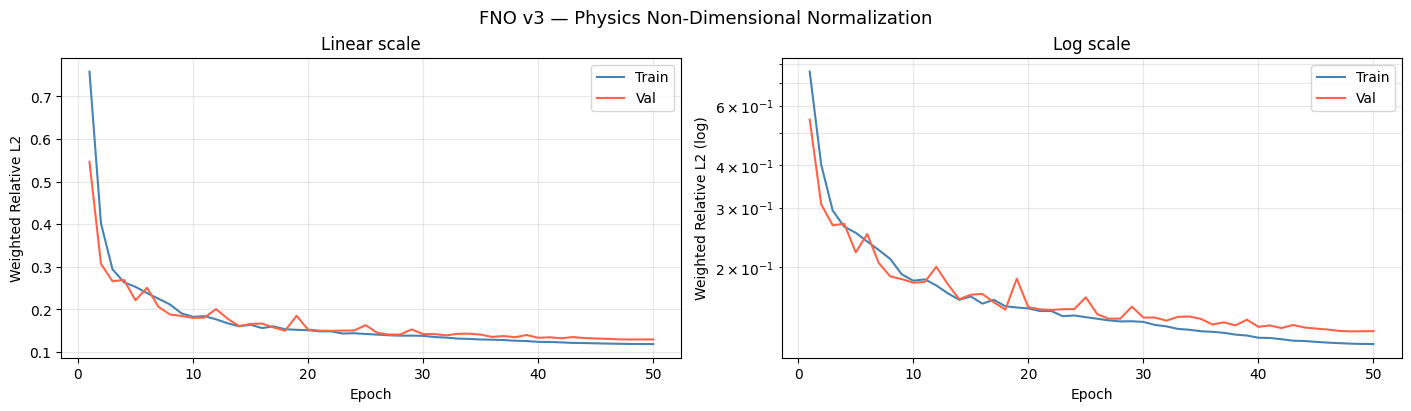

Best val : 0.1291 | Epochs : 50


In [ ]:
# ── 8. Loss Curves ─────────────────────────────────────────────────────────────
epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig.suptitle('FNO v3 — Physics Non-Dimensional Normalization', fontsize=13)

axes[0].plot(epochs, train_losses, label='Train', color='steelblue')
axes[0].plot(epochs, val_losses,   label='Val',   color='tomato')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted Relative L2')
axes[0].set_title('Linear scale'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(epochs, train_losses, label='Train', color='steelblue')
axes[1].semilogy(epochs, val_losses,   label='Val',   color='tomato')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Weighted Relative L2 (log)')
axes[1].set_title('Log scale'); axes[1].legend(); axes[1].grid(alpha=0.3, which='both')

plt.savefig(os.path.join(CKPT_DIR, 'stage2_v3_loss.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Best val : {best_val:.4f} | Epochs : {len(train_losses)}')

Loaded best_model_v3.pt from epoch 48 (val=0.1291)


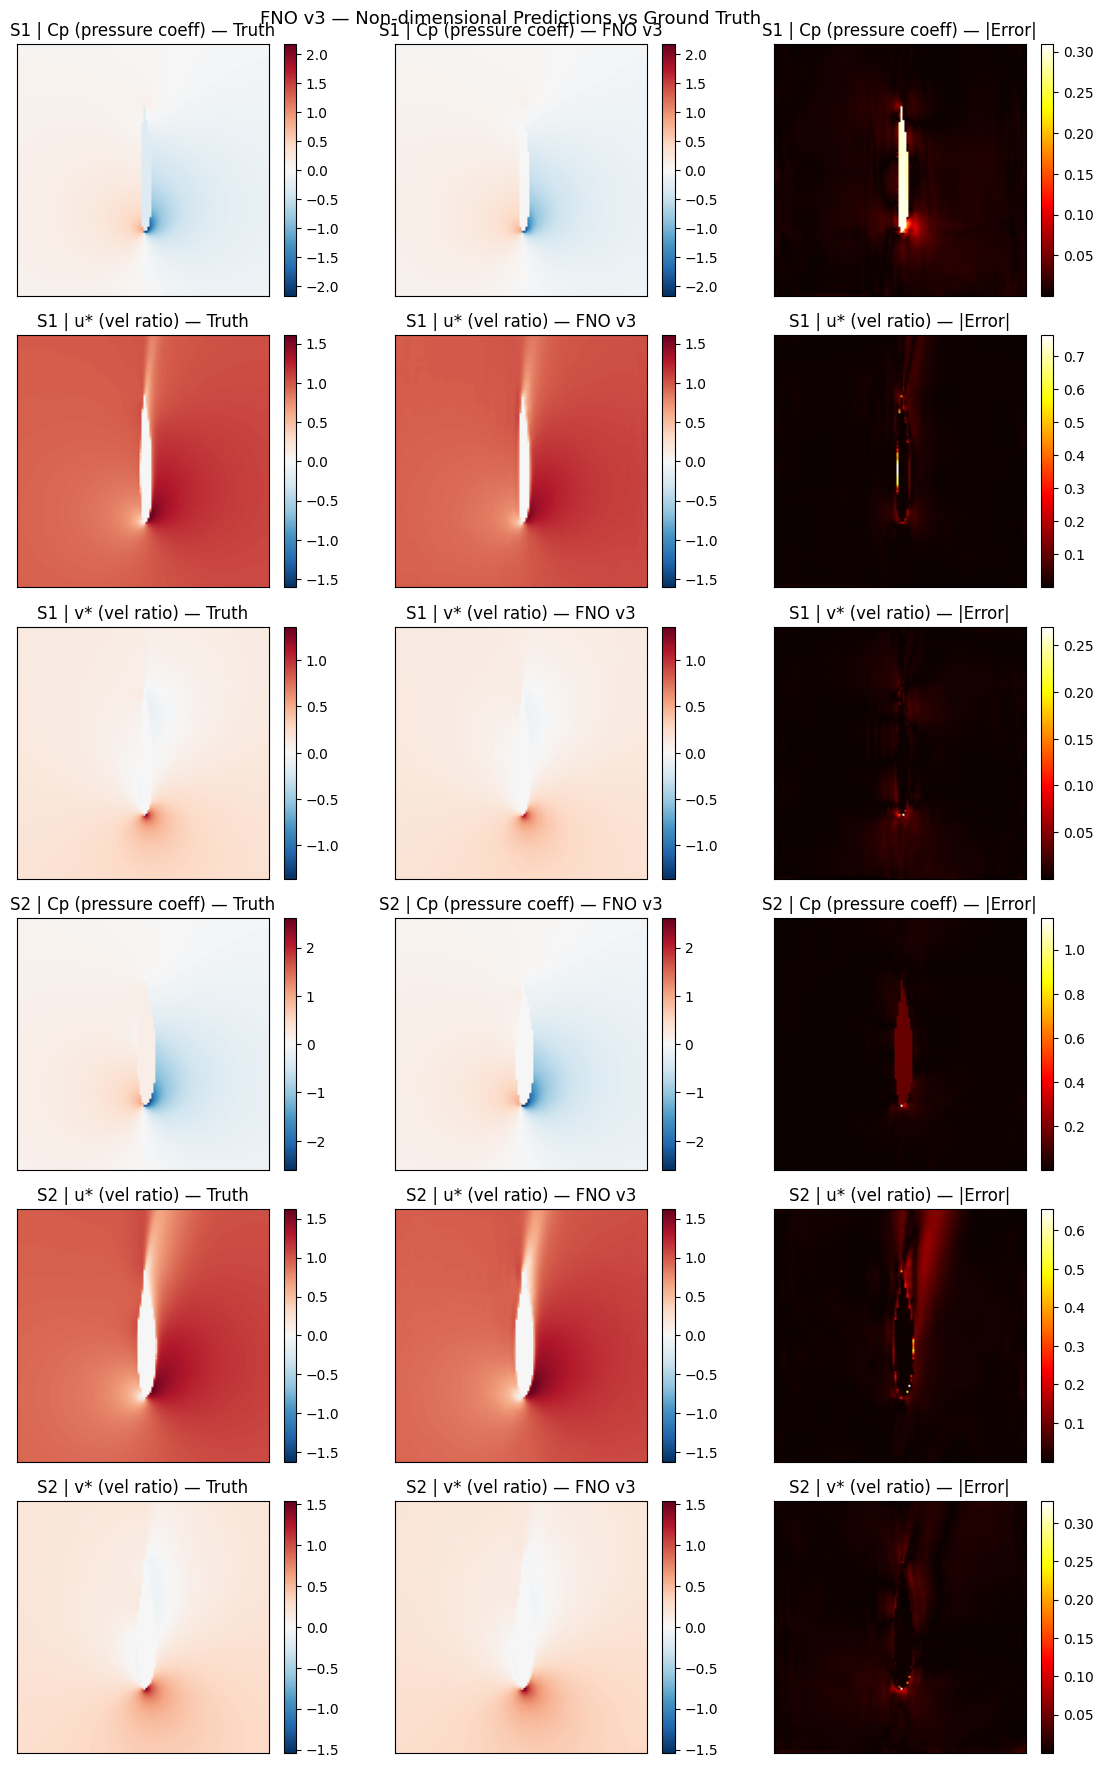

In [ ]:
# ── 9. Visual Prediction Check ─────────────────────────────────────────────────
ckpt = torch.load(
    os.path.join(CKPT_DIR, 'best_model_v3.pt'),
    map_location=device, weights_only=False
)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best_model_v3.pt from epoch {ckpt["epoch"]} (val={ckpt["val_loss"]:.4f})')

CHANNEL_NAMES = ['Cp (pressure coeff)', 'u* (vel ratio)', 'v* (vel ratio)']
N_SAMPLES     = 2

val_iter     = iter(val_loader)
x_val, y_val = next(val_iter)

with torch.no_grad():
    pred_val = model(x_val.to(device)).cpu()

fig, axes = plt.subplots(N_SAMPLES * 3, 3, figsize=(12, N_SAMPLES * 9))
fig.suptitle('FNO v3 — Non-dimensional Predictions vs Ground Truth', fontsize=13)

for s in range(N_SAMPLES):
    for c, ch_name in enumerate(CHANNEL_NAMES):
        row  = s * 3 + c
        gt   = y_val[s, c].numpy()
        pr   = pred_val[s, c].numpy()
        err  = np.abs(gt - pr)
        vmax = max(np.abs(gt).max(), 0.01)

        im0 = axes[row,0].imshow(gt,  origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        im1 = axes[row,1].imshow(pr,  origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        im2 = axes[row,2].imshow(err, origin='lower', cmap='hot')

        axes[row,0].set_title(f'S{s+1} | {ch_name} — Truth')
        axes[row,1].set_title(f'S{s+1} | {ch_name} — FNO v3')
        axes[row,2].set_title(f'S{s+1} | {ch_name} — |Error|')

        for ax, im in zip(axes[row], [im0, im1, im2]):
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'stage2_v3_predictions.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── 10. Per-channel Error Summary ──────────────────────────────────────────────
model.eval()
ch_errors = [[] for _ in range(3)]

with torch.no_grad():
    for x_b, y_b in val_loader:
        pred_b = model(x_b.to(device)).cpu()
        for c in range(3):
            rel = (pred_b[:, c] - y_b[:, c]).pow(2).sum(dim=(-2,-1)).sqrt() / \
                  (y_b[:, c].pow(2).sum(dim=(-2,-1)).sqrt() + 1e-8)
            ch_errors[c].extend(rel.tolist())

ch_names = ['Cp (pressure)', 'u*', 'v*']
print('Per-channel relative L2 on validation set (v3 — non-dimensional):')
print('-'*55)
for c, name in enumerate(ch_names):
    mean_err = np.mean(ch_errors[c])
    flag = '✓' if mean_err < 0.15 else ('~' if mean_err < 0.30 else '✗')
    print(f'  {flag} {name:<15} : {mean_err:.4f}  ({mean_err*100:.1f}%)')

print()
print('Previous versions for comparison:')
print('  v1 (z-score)     — pressure: 51.1% | u: 3.9% | v: 8.6%')
print('  v2 (dynamic norm) — pressure: 50.3% | u: 3.9% | v: 8.5%')

Per-channel relative L2 on validation set (v3 — non-dimensional):
-------------------------------------------------------
  ~ Cp (pressure)   : 0.2413  (24.1%)
  ✓ u*              : 0.0486  (4.9%)
  ✓ v*              : 0.0975  (9.7%)

Previous versions for comparison:
  v1 (z-score)     — pressure: 51.1% | u: 3.9% | v: 8.6%
  v2 (dynamic norm) — pressure: 50.3% | u: 3.9% | v: 8.5%


In [ ]:
model.eval()
drag_errors = []

with torch.no_grad():
    for x_b, y_b in val_loader:
        pred_b = model(x_b.to(device)).cpu()
        for i in range(y_b.shape[0]):
            geom = x_b[i, 2].numpy()
            gt_p = y_b[i, 0].numpy()
            pr_p = pred_b[i, 0].numpy()
            mask = geom > 0.5
            if mask.sum() < 10:
                continue
            gt_surf = gt_p[mask].mean()
            pr_surf = pr_p[mask].mean()
            rel_err = abs(pr_surf - gt_surf) / (abs(gt_surf) + 1e-8)
            drag_errors.append(rel_err)

print(f'Surface Cp relative error : {np.mean(drag_errors)*100:.1f}%')
print(f'Full field Cp error       : 24.1%')
print(f'v1/v2 surface error was   : 145.4%')

Surface Cp relative error : 143.5%
Full field Cp error       : 24.1%
v1/v2 surface error was   : 145.4%
